In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/financial-anomaly-data/financial_anomaly_data.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=[10,5]

In [3]:
df=pd.read_csv('/kaggle/input/financial-anomaly-data/financial_anomaly_data.csv')
df.head()

,Timestamp,TransactionID,AccountID,Amount,Merchant,TransactionType,Location
0,01-01-2023 08:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo
1,01-01-2023 08:01,TXN1639,ACC10,15607.89,MerchantH,Purchase,London
2,01-01-2023 08:02,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London
3,01-01-2023 08:03,TXN1438,ACC6,87.87,MerchantE,Purchase,London
4,01-01-2023 08:04,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles


In [4]:
df.shape

(217441, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217441 entries, 0 to 217440
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamp        216960 non-null  object 
 1   TransactionID    216960 non-null  object 
 2   AccountID        216960 non-null  object 
 3   Amount           216960 non-null  float64
 4   Merchant         216960 non-null  object 
 5   TransactionType  216960 non-null  object 
 6   Location         216960 non-null  object 
dtypes: float64(1), object(6)
memory usage: 11.6+ MB


In [6]:
df.isnull().sum()

Timestamp          481
TransactionID      481
AccountID          481
Amount             481
Merchant           481
TransactionType    481
Location           481
dtype: int64

In [7]:
df=df.dropna()
df.shape

(216960, 7)

In [8]:
df.columns

Index(['Timestamp', 'TransactionID', 'AccountID', 'Amount', 'Merchant',
       'TransactionType', 'Location'],
      dtype='object')

In [9]:
df.nunique()

Timestamp          216960
TransactionID        1999
AccountID              15
Amount             214687
Merchant               10
TransactionType         3
Location                5
dtype: int64

In [10]:
import datetime

In [11]:
from datetime import datetime

date_string = "01-01-2023 08:00"
time_series_format = datetime.strptime(date_string, "%d-%m-%Y %H:%M")
print(time_series_format)


2023-01-01 08:00:00


In [12]:
def time_format(x):
    time_series_format = datetime.strptime(x, "%d-%m-%Y %H:%M")
    return time_series_format
    

In [13]:
time_format("01-01-2023 08:00")

datetime.datetime(2023, 1, 1, 8, 0)

In [14]:
df['Timestamp']=df['Timestamp'].apply(time_format)
df.head()

,Timestamp,TransactionID,AccountID,Amount,Merchant,TransactionType,Location
0,2023-01-01 08:00:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo
1,2023-01-01 08:01:00,TXN1639,ACC10,15607.89,MerchantH,Purchase,London
2,2023-01-01 08:02:00,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London
3,2023-01-01 08:03:00,TXN1438,ACC6,87.87,MerchantE,Purchase,London
4,2023-01-01 08:04:00,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles


In [15]:
df=df.set_index('Timestamp')
df.head()

,TransactionID,AccountID,Amount,Merchant,TransactionType,Location
Timestamp,,,,,,
2023-01-01 08:00:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo
2023-01-01 08:01:00,TXN1639,ACC10,15607.89,MerchantH,Purchase,London
2023-01-01 08:02:00,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London
2023-01-01 08:03:00,TXN1438,ACC6,87.87,MerchantE,Purchase,London
2023-01-01 08:04:00,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles


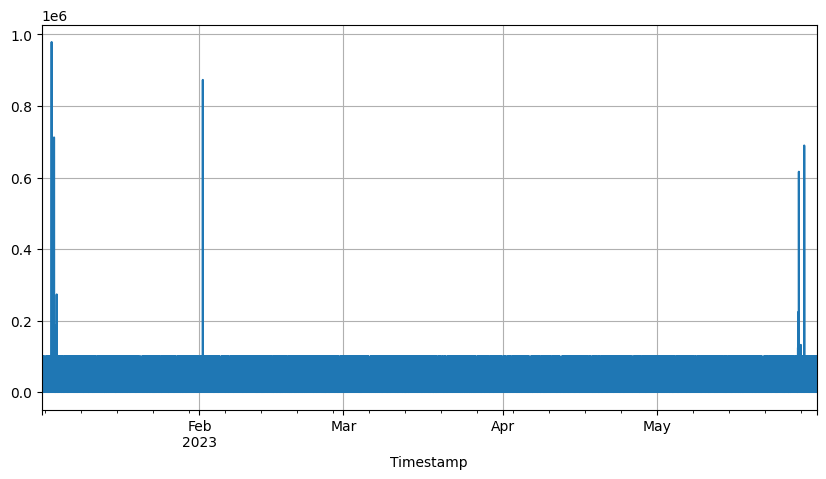

In [16]:
df['Amount'].plot()
plt.grid()
plt.show()

In [17]:
df['TransactionID'].nunique()

1999

In [18]:
df['AccountID'].nunique()

15

In [19]:
df.groupby(['AccountID'])['TransactionID'].count()

AccountID
ACC1     14365
ACC10    14362
ACC11    14446
ACC12    14421
ACC13    14421
ACC14    14458
ACC15    14701
ACC2     14553
ACC3     14285
ACC4     14456
ACC5     14630
ACC6     14352
ACC7     14581
ACC8     14402
ACC9     14527
Name: TransactionID, dtype: int64

In [20]:
for i,j in zip(df.groupby(['AccountID'])['TransactionID'].count().index,df.groupby(['AccountID'])['TransactionID'].count().values):
    print(f"The total transactions for account {i} is {j}")

The total transactions for account ACC1 is 14365
The total transactions for account ACC10 is 14362
The total transactions for account ACC11 is 14446
The total transactions for account ACC12 is 14421
The total transactions for account ACC13 is 14421
The total transactions for account ACC14 is 14458
The total transactions for account ACC15 is 14701
The total transactions for account ACC2 is 14553
The total transactions for account ACC3 is 14285
The total transactions for account ACC4 is 14456
The total transactions for account ACC5 is 14630
The total transactions for account ACC6 is 14352
The total transactions for account ACC7 is 14581
The total transactions for account ACC8 is 14402
The total transactions for account ACC9 is 14527


In [21]:
for i,j in zip(df.groupby(['AccountID'])['Amount'].mean().index,df.groupby(['AccountID'])['Amount'].mean().values):
    print(f"The average transaction amount for account {i} is {j}")

The average transaction amount for account ACC1 is 50428.5296484511
The average transaction amount for account ACC10 is 49729.92767581117
The average transaction amount for account ACC11 is 49662.176511837184
The average transaction amount for account ACC12 is 50272.45223840233
The average transaction amount for account ACC13 is 50538.807350391784
The average transaction amount for account ACC14 is 50013.096792087425
The average transaction amount for account ACC15 is 50371.89460580913
The average transaction amount for account ACC2 is 50047.96155225727
The average transaction amount for account ACC3 is 49910.79913545677
The average transaction amount for account ACC4 is 49623.77805962922
The average transaction amount for account ACC5 is 50194.70615584415
The average transaction amount for account ACC6 is 50038.08343297101
The average transaction amount for account ACC7 is 50079.504645086075
The average transaction amount for account ACC8 is 50481.295046521314
The average transaction 

In [22]:
df['Amount'].max(),df['Amount'].min()

(978942.26, 10.51)

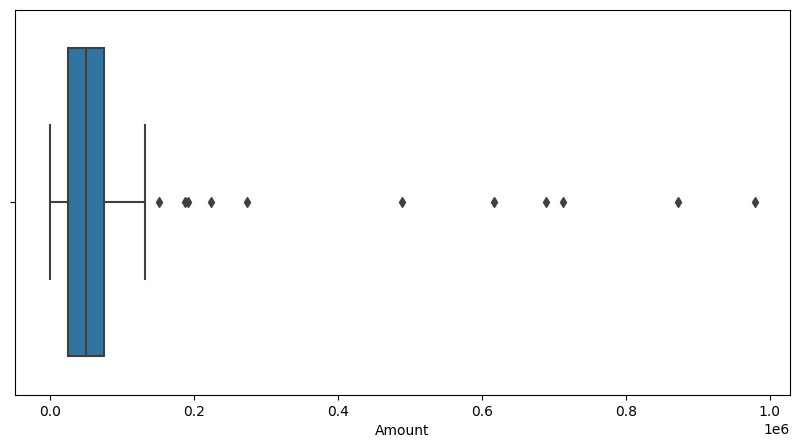

In [23]:
sns.boxplot(x=df['Amount'])
plt.show()

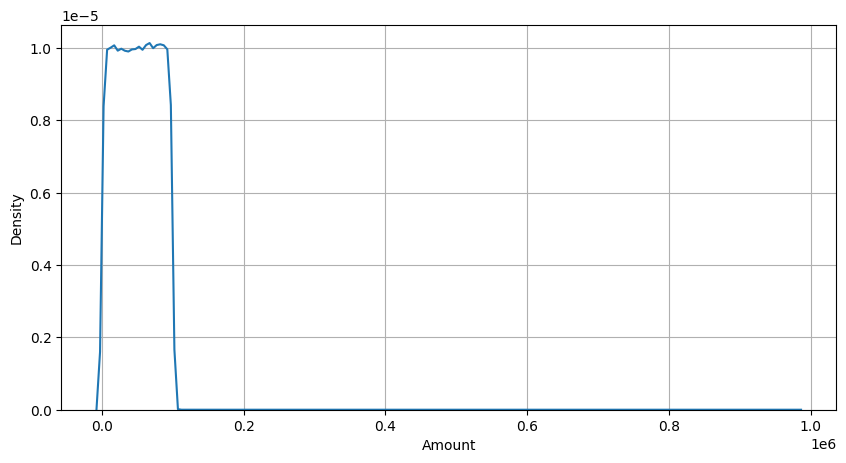

In [24]:
sns.kdeplot(x=df['Amount'])

plt.grid()
plt.show()

In [25]:
# Lets check the min and max transactions

In [26]:
df.columns

Index(['TransactionID', 'AccountID', 'Amount', 'Merchant', 'TransactionType',
       'Location'],
      dtype='object')

In [27]:
print("The details for minimum transaction are:\n")

for i,j in zip(df.columns,df[df['Amount']==df['Amount'].min()].values[0]):
    print(f"{i} : {j}")
    

The details for minimum transaction are:

TransactionID : TXN1805
AccountID : ACC1
Amount : 10.51
Merchant : MerchantD
TransactionType : Purchase
Location : London


In [28]:
print("The details for maximum transaction are:\n")

for i,j in zip(df.columns,df[df['Amount']==df['Amount'].max()].values[0]):
    print(f"{i} : {j}")
    

The details for maximum transaction are:

TransactionID : TXN1049
AccountID : ACC14
Amount : 978942.26
Merchant : MerchantJ
TransactionType : Transfer
Location : New York


In [29]:
# Let's deep dive more into data

In [30]:
df.head()

,TransactionID,AccountID,Amount,Merchant,TransactionType,Location
Timestamp,,,,,,
2023-01-01 08:00:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo
2023-01-01 08:01:00,TXN1639,ACC10,15607.89,MerchantH,Purchase,London
2023-01-01 08:02:00,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London
2023-01-01 08:03:00,TXN1438,ACC6,87.87,MerchantE,Purchase,London
2023-01-01 08:04:00,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles


In [31]:
amt=pd.Series(np.random.random_integers(0,1000000,size=df.shape[0]))

#amt=pd.Series(np.random.random_integers(df['Amount'].min(),df['Amount'].max(),size=df.shape[0]))
amt

0         995824
1         466635
2         790642
3         949040
4         957154
           ...  
216955    279202
216956    608884
216957    727236
216958     85288
216959    662015
Length: 216960, dtype: int64

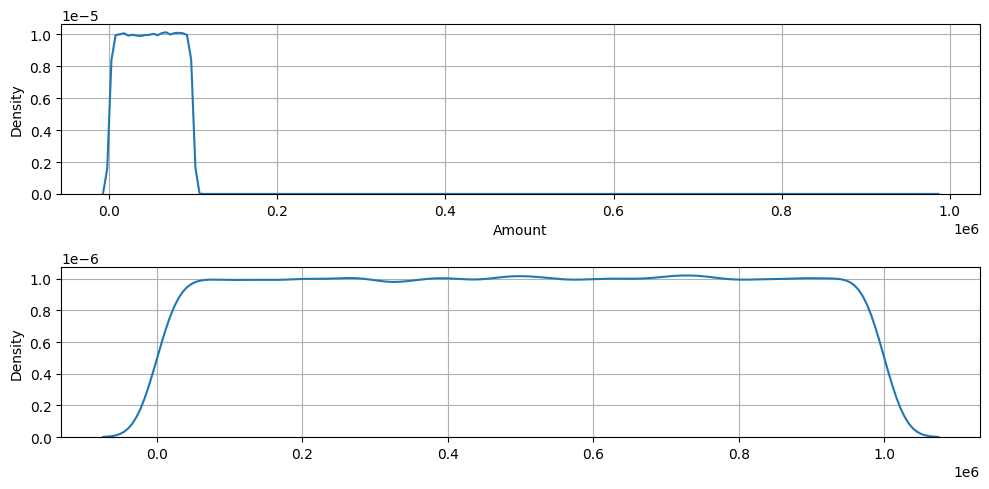

In [32]:
plt.subplot(2,1,1)
sns.kdeplot(df['Amount'])
plt.grid()
plt.subplot(2,1,2)
sns.kdeplot(amt)
plt.grid()

plt.tight_layout()
plt.show()

In [33]:
q1=df['Amount'].quantile(0.25)
q3=df['Amount'].quantile(0.75)
iqr=q3-q1
ll=q1-(1.5*iqr)
ul=q3+(1.5*iqr)

In [34]:
ll

-49967.58374999998

In [35]:
ul

150109.28624999998

In [36]:
# Let's set a baseline bench mark for the transacations above amount 0, by using the boxplot and statistical concepts

In [37]:
trigger_list=[]
for i in df['Amount']:
    if i>ul:
        trigger_list.append("EXCEEDING")
    else:
        trigger_list.append("NOT EXCEEDING")

In [38]:
len(trigger_list)

216960

In [39]:
trigger_df=pd.DataFrame({'Amount':df['Amount'],'trigger':trigger_list})
trigger_df

,Amount,trigger
Timestamp,,
2023-01-01 08:00:00,95071.92,NOT EXCEEDING
2023-01-01 08:01:00,15607.89,NOT EXCEEDING
2023-01-01 08:02:00,65092.34,NOT EXCEEDING
2023-01-01 08:03:00,87.87,NOT EXCEEDING
2023-01-01 08:04:00,716.56,NOT EXCEEDING
...,...,...
2023-05-31 23:55:00,62536.88,NOT EXCEEDING
2023-05-31 23:56:00,68629.69,NOT EXCEEDING
2023-05-31 23:57:00,8203.57,NOT EXCEEDING


In [40]:
trigger_df['trigger'].value_counts()

trigger
NOT EXCEEDING    216949
EXCEEDING            11
Name: count, dtype: int64

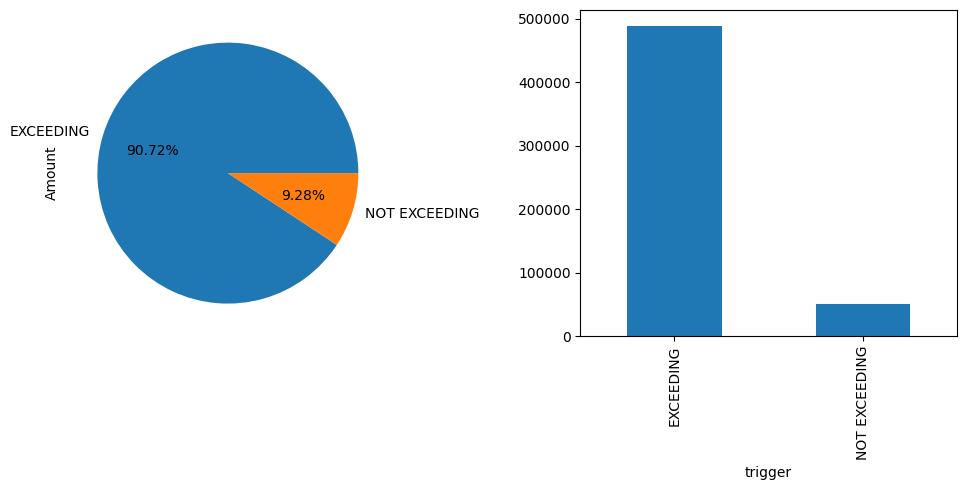

In [41]:
plt.subplot(1,2,1)
trigger_df.groupby('trigger')['Amount'].mean().plot(kind='pie',autopct='%0.2f%%')
plt.subplot(1,2,2)
trigger_df.groupby('trigger')['Amount'].mean().plot(kind='bar')

plt.tight_layout()
plt.show()

In [42]:
# The average exceeding limit amount accounts for 90.72% while non-exceeding amount accounts for 9.28%
# The exceeding limit is based on the upperlimit for the distribution of "Amount". 